# The Asset Diversification Effect
The purpose of this notebook is to demonstrate how increasing the number of portfolio
assets can improve portfolio performance.

Whilst single stocks can often be volatile, spreading investments across different
asset classes, sectors and geographies allows underperfoming assets to be offset by gains
in others. This creates more stable and consistent long-term gains.

## Imports

In [22]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [2]:
# Load data for the last 3 years
start_date = date.today() - relativedelta(years=3)
start_date

datetime.date(2023, 6, 4)

In [3]:
# Load ccollection of S&P500 stocks from repository
df_stocks = tad.get_sp500(start_date=start_date)

# We will be testing only on complete data across the time period
df_stocks = df_stocks.dropna(how='any', axis=1)

In [4]:
ht(df_stocks)

Price            Close                                                 \
Ticker               A        AAPL        ABBV         ABT       ACGL   
Date                                                                    
2023-06-05  115.679420  177.260406  123.926559   98.316544  67.799065   
2023-06-06  114.789955  176.895172  122.631676   97.236351  67.703972   
2023-06-07  113.959122  175.523132  123.600578   96.326714  67.751518   
2026-04-08  116.919998  258.899994  211.589996  103.559998  98.599998   
2026-04-09  115.389999  260.489990  212.399994  102.720001  98.839996   
2026-04-10  115.059998  260.480011  207.940002  100.300003  95.970001   

Price                                                                  ...  \
Ticker             ACN        ADBE         ADI        ADM         ADP  ...   
Date                                                                   ...   
2023-06-05  290.666656  434.179993  167.155441  64.958435  201.884216  ...   
2023-06-06  294.094116  432.890015  170.011765  65.979256  202.351044  ...   
2023-06-07  296.948639  418.320007  172.304428  66.863365  202.098953  ...   
2026-04-08  192.209991  239.309998  346.209991  71.720001  200.779999  ...   
2026-04-09  186.029999  229.940002  351.359985  70.349998  196.020004  ...   
2026-04-10  179.529999  225.350006  350.140015  69.730003  188.789993  ...   

Price         Volume                                                          \
Ticker           WTW         WY       WYNN        XEL         XOM        XYL   
Date                                                                           
2023-06-05  269600.0  2922100.0  1917400.0  3168700.0  10628000.0  2253700.0   
2023-06-06  485800.0  2810100.0  2701900.0  3062900.0  12209800.0  1568300.0   
2023-06-07  395400.0  2909600.0  1641600.0  3953800.0  16027100.0  1857000.0   
2026-04-08  574200.0  3955400.0  2548000.0  4283300.0  31311200.0  2933600.0   
2026-04-09  635600.0  3160900.0  1333300.0  3956200.0  25868400.0  2303600.0   
2026-04-10  921300.0  3719000.0   790900.0  3515400.0  21059600.0  1626900.0   

Price                                                  
Ticker            YUM        ZBH      ZBRA        ZTS  
Date                                                   
2023-06-05  1562700.0   993800.0  491400.0  1500200.0  
2023-06-06  1604200.0   787100.0  455100.0  1802900.0  
2023-06-07  1801000.0  2151800.0  266300.0  3195100.0  
2026-04-08  1213500.0  2128500.0  788900.0  2635500.0  
2026-04-09  1184400.0  1712400.0  608100.0  2439100.0  
2026-04-10  1458400.0  1769300.0  552600.0  2384000.0  

[6 rows x 2185 columns]

In [5]:
# Dataset should be complete without any missing price points
df_stocks.isna().any().any()

np.False_

In [6]:
df_stocks.shape

(715, 2185)

In [7]:
print(df_stocks.columns.get_level_values(1).nunique(), 'stocks')

437 stocks


## Simulating Thousands of Randomly Allocated Portfolios with Increasing Number of Assets

In [8]:
# The number of assets that will be included in the max portfolio
n_assets = 20
# The number of simulations per portfolio size
i_simulations = 1000
# Initialize lists that will form the final dataset
ewp_n_assets = []
ewp_run_num = []
ewp_tickers = []
ewp_risk = []
ewp_return = []
ewp_sharpe = []

# Number of assets in the portfolio
for n in range(1, n_assets+1):
    # Number of randomly allocated n sized portfolios to generate
    for i in range(1, i_simulations+1):

        # Generate a unique seed for each simulation so that results
        # are repeatable
        random.seed(i)
        f1 = random.randint(1, 1000)
        random.seed(n)
        f2 = random.randint(1, 1000)
        seed = f1*f2

        # Select a random portfolio of n assets from available stocks
        tickers = tao.select_n(n, df_stocks.columns.get_level_values(1).unique().tolist(), seed=seed)
        # Calculate equal weighted portfolio returns
        df_returns = tao.portfolio_returns(df_stocks.loc[:, pd.IndexSlice[:, tickers]], method='EWP')
        # Calculate summary statistics for the portfolio
        df_summary = tau.get_returns_summary(df_returns)

        # Store simulation values
        ewp_n_assets.append(n)
        ewp_run_num.append(i)
        ewp_tickers.append(tickers)
        ewp_risk.append(df_summary.loc['EWP', 'Risk'])
        ewp_return.append(df_summary.loc['EWP', 'Return'])
        ewp_sharpe.append(df_summary.loc['EWP', 'Sharpe'])
        
df_diversification = pd.DataFrame({'N Assets': ewp_n_assets, 
                                   'I Run': ewp_run_num, 
                                #    'tickers': ewp_tickers, 
                                   'Risk': ewp_risk, 
                                   'Return':ewp_return,
                                   'Sharpe': ewp_sharpe})

In [9]:
ht(df_diversification)

,N Assets,I Run,Risk,Return,Sharpe
0,1,1,0.373339,-0.033858,-0.090689
1,1,2,0.225137,0.276328,1.227377
2,1,3,0.230937,0.131356,0.568795
19997,20,998,0.163733,0.145755,0.890199
19998,20,999,0.152722,0.163319,1.069393
19999,20,1000,0.148297,0.094305,0.635915


In [20]:
df_grouped = df_diversification.groupby('N Assets').mean()[['Return', 'Risk', 'Sharpe']]
df_grouped.index = df_grouped.index.astype(str)
df_grouped

,Return,Risk,Sharpe
N Assets,,,
1,0.145905,0.284609,0.536326
2,0.156173,0.227173,0.696703
3,0.154434,0.203594,0.768036
4,0.151082,0.187897,0.810998
5,0.168337,0.179380,0.945727
6,0.156381,0.173585,0.903996
7,0.156519,0.169805,0.925873
8,0.160949,0.166243,0.973824
9,0.163393,0.163698,1.003129


## Visualizing Performance as Number of Assets Increases

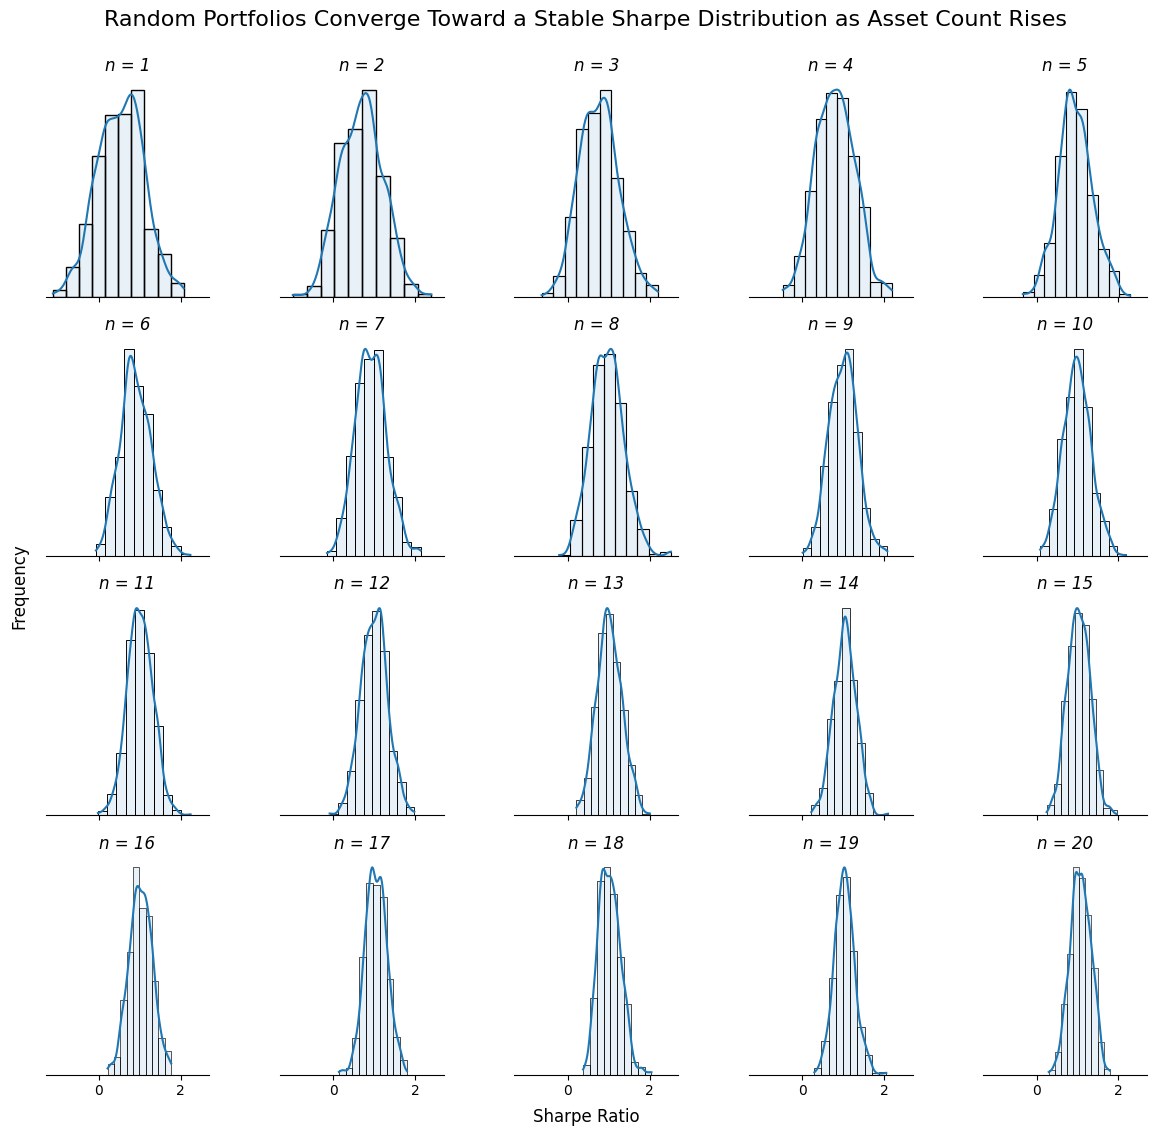

In [42]:
# 5 rows, 4 columns
r,c = 4,5
fig, ax = plt.subplots(r, c, figsize=(12, 12), tight_layout=True, sharex=True)

fig.tight_layout(pad=2, rect=[0,0.05,1,0.95])
fig.suptitle(f'Random Portfolios Converge Toward a Stable Sharpe Distribution as Asset Count Rises',
             fontsize=16)
fig.supxlabel('Sharpe Ratio', y=0.05, fontsize=12)
fig.supylabel('Frequency', fontsize=12)

for n in df_diversification['N Assets'].unique():

    # Axes row
    ax_r = int(np.floor((n-1)/c))
    # Axes column
    ax_c = int((n-1)%c)
    # Axes subplot
    ax_p = ax[ax_r, ax_c]

    ax_p.set_title(f'n = {n}', fontsize=12, fontstyle='italic')
    ax_p.spines[['left','top', 'right']].set_visible(False)
    ax_p.set_yticklabels([])
    ax_p.set_yticks([])
    ax_p.set_ylabel(' ')
    ax_p.set_xlabel(' ')

    sns.histplot(
        df_diversification[df_diversification['N Assets']==n]['Sharpe'], 
        ax=ax_p,
        alpha=0.1,
        kde=True,
        bins=10)

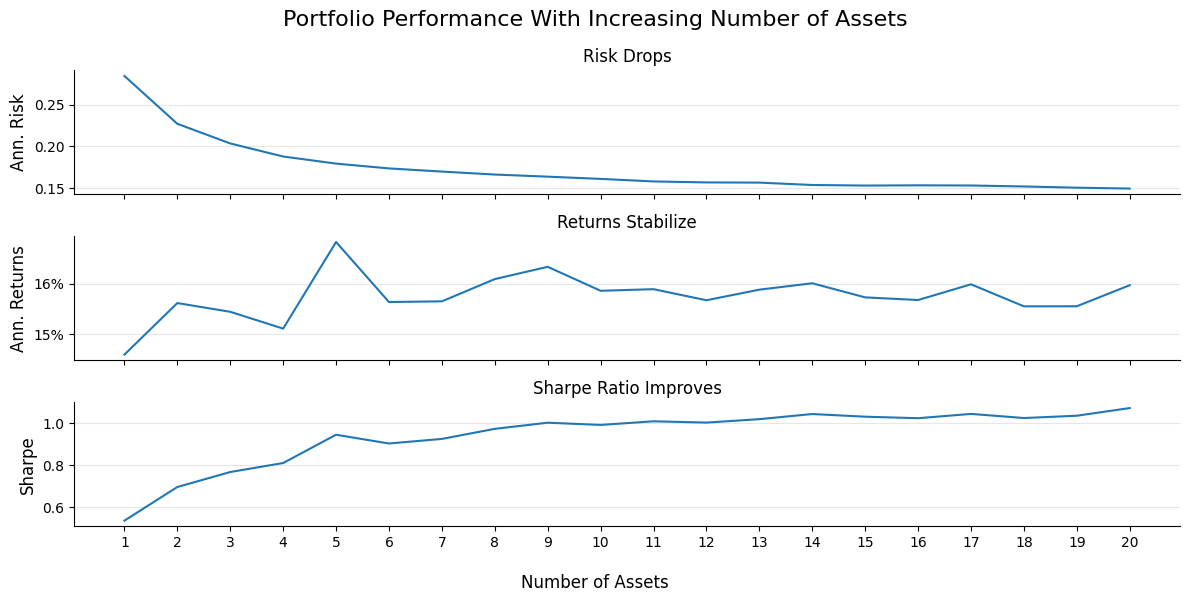

In [41]:
fig, ax = plt.subplots(3, 1, figsize=(12, 6), tight_layout=True, sharex=True)

fig.suptitle('Portfolio Performance With Increasing Number of Assets', fontsize=16)
fig.supxlabel('Number of Assets')

ax[0].set_title('Risk Drops')
ax[0].set_ylabel('Ann. Risk',fontsize=12)
ax[0].plot(df_grouped['Risk'])
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].grid(axis='y', alpha=0.3)


ax[1].set_title('Returns Stabilize')
ax[1].set_ylabel('Ann. Returns',fontsize=12)
ax[1].plot(df_grouped['Return'])
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].grid(axis='y', alpha=0.3)

ax[2].set_title('Sharpe Ratio Improves')
ax[2].set_ylabel('Sharpe',fontsize=12)
ax[2].plot(df_grouped['Sharpe'])
ax[2].spines[['top', 'right']].set_visible(False)
ax[2].grid(axis='y', alpha=0.3)

plt.show();